# Laplace approximation for non-conjugate GPs

When the likelihood $p(y \mid f)$ is not Gaussian, the posterior $p(f \mid y) \propto p(y \mid f)\,p(f)$ no longer admits a closed-form Gaussian. The Laplace approximation replaces it with a Gaussian centered at the posterior mode $\hat f$ with covariance set to the inverse of the negative log-posterior Hessian at that mode:

$$q(f) = \mathcal{N}(f \mid \hat f, (\Lambda + K^{-1})^{-1}), \qquad \Lambda = -\nabla^2_f \log p(y \mid f)\big|_{\hat f}.$$

**Newton iteration.** Each step solves a linear-Gaussian regression with synthetic per-point precision $\Lambda_n$ and synthetic targets $\tilde y_n = (\Lambda_n f_n + g_n)/\Lambda_n$, where $g_n = \partial_{f_n} \log p(y_n \mid f_n)$. This is the standard GP-Laplace fixed-point iteration (Rasmussen & Williams, Algorithm 3.1). For log-concave likelihoods (Bernoulli, Poisson) it converges quadratically.

**Approximate log marginal.**
$$\log p(y) \approx \log p(y \mid \hat f) - \tfrac12 \hat f^\top K^{-1} \hat f - \tfrac12 \log|I + K\Lambda|.$$

This notebook fits Laplace on a 1-D Bernoulli classification problem and inspects the convergence trace, posterior mean / variance, and predictive distribution.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from pyrox.gp import RBF, BernoulliLikelihood, GPPrior, LaplaceInference


plt.rcParams["figure.dpi"] = 110
key = jax.random.PRNGKey(0)

/home/azureuser/localfiles/pyrox/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Synthetic 1-D classification

Latent function $f(x) = 2\sin(x) + 0.4\,x$, observations $y_n \sim \text{Bernoulli}(\sigma(f(x_n)))$.

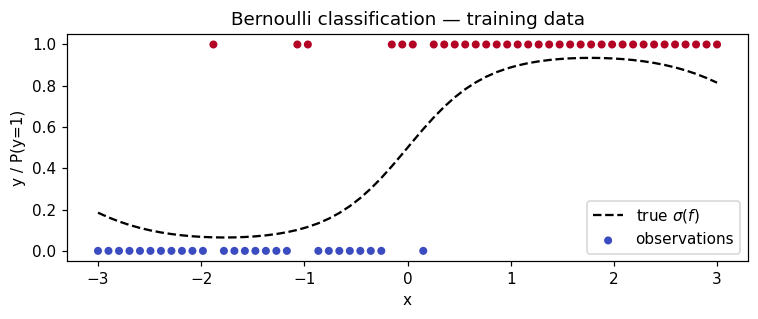

In [2]:
N = 60
X = jnp.linspace(-3.0, 3.0, N)[:, None]
f_true = 2.0 * jnp.sin(X[:, 0]) + 0.4 * X[:, 0]
probs_true = jax.nn.sigmoid(f_true)
y = (jax.random.uniform(key, (N,)) < probs_true).astype(jnp.float32)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(X[:, 0], probs_true, "k--", lw=1.5, label=r"true $\sigma(f)$")
ax.scatter(X[:, 0], y, c=y, cmap="coolwarm", s=18, label="observations")
ax.set_xlabel("x")
ax.set_ylabel("y / P(y=1)")
ax.legend()
ax.set_title("Bernoulli classification — training data")
plt.tight_layout()
plt.show()

## Fit

RBF prior, lengthscale 0.6, variance 1.5. We run Laplace to convergence and inspect the iteration count.

In [3]:
prior = GPPrior(kernel=RBF(init_lengthscale=0.6, init_variance=1.5), X=X)
# Newton's method on a log-concave likelihood converges quadratically; the
# ``tol`` is on the inf-norm change in ``f``. Default ``tol=1e-6`` is well
# above float32 noise and gives a few-iteration fit.
strategy = LaplaceInference(max_iter=50, tol=1e-6)
cond = strategy.fit(prior, BernoulliLikelihood(), y)

print(f"converged: {cond.converged}")
print(f"iterations used: {cond.n_iter}")
print(f"approximate log marginal: {float(cond.log_marginal_approx):.4f}")
print(
    f"posterior mean range: [{float(cond.q_mean.min()):.3f}, {float(cond.q_mean.max()):.3f}]"
)
print(
    f"posterior var range:  [{float(cond.q_var.min()):.4f}, {float(cond.q_var.max()):.4f}]"
)

converged: True
iterations used: 6
approximate log marginal: -25.6915
posterior mean range: [-1.887, 2.245]
posterior var range:  [0.3910, 0.8180]


## Predictive distribution

Predict the latent at a fine grid, then push the mean ±2σ through $\sigma(\cdot)$ to get a probabilistic decision boundary.

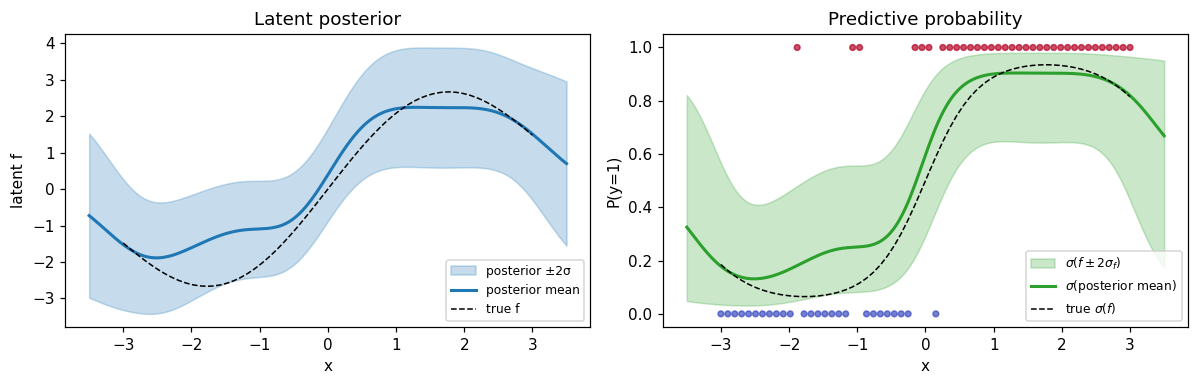

In [4]:
X_star = jnp.linspace(-3.5, 3.5, 200)[:, None]
m_star, v_star = cond.predict(X_star)
m_star, v_star = np.asarray(m_star), np.asarray(v_star)
sd_star = np.sqrt(np.maximum(v_star, 0))
p_mean = jax.nn.sigmoid(m_star)
p_lo = jax.nn.sigmoid(m_star - 2.0 * sd_star)
p_hi = jax.nn.sigmoid(m_star + 2.0 * sd_star)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
ax = axes[0]
ax.fill_between(
    X_star[:, 0],
    m_star - 2.0 * sd_star,
    m_star + 2.0 * sd_star,
    alpha=0.25,
    color="C0",
    label="posterior ±2σ",
)
ax.plot(X_star[:, 0], m_star, color="C0", lw=2, label="posterior mean")
ax.plot(X[:, 0], f_true, "k--", lw=1, label="true f")
ax.set_xlabel("x")
ax.set_ylabel("latent f")
ax.set_title("Latent posterior")
ax.legend(loc="lower right", fontsize=8)

ax = axes[1]
ax.fill_between(
    X_star[:, 0], p_lo, p_hi, alpha=0.25, color="C2", label=r"$\sigma(f \pm 2\sigma_f)$"
)
ax.plot(X_star[:, 0], p_mean, color="C2", lw=2, label=r"$\sigma$(posterior mean)")
ax.plot(X[:, 0], probs_true, "k--", lw=1, label=r"true $\sigma(f)$")
ax.scatter(X[:, 0], y, c=y, cmap="coolwarm", s=14, alpha=0.7)
ax.set_xlabel("x")
ax.set_ylabel("P(y=1)")
ax.set_title("Predictive probability")
ax.legend(loc="lower right", fontsize=8)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

## Diagnostic — site precisions

The Laplace approximation gives each observation a Gaussian *site* with diagonal precision $\Lambda_n = \sigma(\hat f_n)(1 - \sigma(\hat f_n))$. Sites at confidently-classified points (where $\sigma(\hat f)$ is near 0 or 1) have low precision; sites near the decision boundary (where $\sigma(\hat f) \approx 0.5$) have the largest precision $= 0.25$.

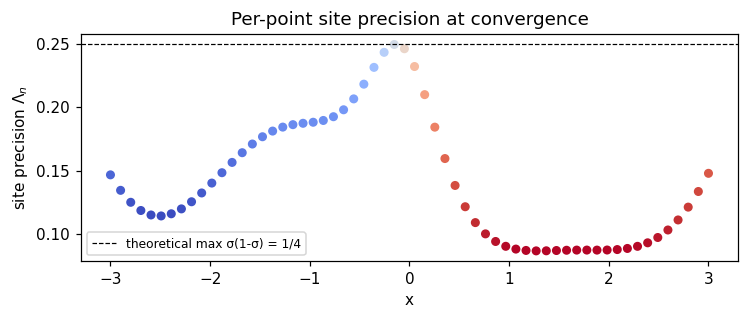

In [5]:
sigma_fhat = jax.nn.sigmoid(cond.q_mean)
fig, ax = plt.subplots(figsize=(7, 3))
ax.scatter(
    X[:, 0], np.asarray(cond.site_nat2), c=np.asarray(sigma_fhat), cmap="coolwarm", s=24
)
ax.axhline(0.25, color="k", ls="--", lw=0.8, label="theoretical max σ(1-σ) = 1/4")
ax.set_xlabel("x")
ax.set_ylabel(r"site precision $\Lambda_n$")
ax.set_title("Per-point site precision at convergence")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Summary

- The Newton loop converges in a small number of iterations (typically ≤ 10) for log-concave likelihoods.
- The posterior mean tracks the true latent; uncertainty grows in regions with sparse data and shrinks where many same-labeled observations cluster.
- Site precisions reflect the standard $\sigma(1-\sigma)$ Bernoulli curvature, peaking near the decision boundary — a useful diagnostic for whether the linearization is well-behaved.

`LaplaceInference` is the simplest entry to non-Gaussian GP inference. Trade-offs against the alternatives (Gauss-Newton, EP, PL, QN) are explored in the companion notebooks.